In [2]:
import os
print(os.getcwd())

/Users/anitanam


In [3]:
import os

print(os.listdir())

['RENEW-SUMMER-2026', 'Exam 1 (Anita Nam) Compressed.zip', 'test1p1.cpp.save', 'meow.json', '.eclipse', '.config', 'Music', 'Homework2.java', 'harm_data.csv', 'model.json', 'Screenshot_Result_HW3P1.png', 'optical_materials_ml', 'Dipole Magnet.json', 'feature_engineering.py', 'CorrectDipole.json', 'Heming.txt', 'Correct quadrupole.json', 'Dipole (Current).json', 'HWWW.java', '.DS_Store', 'master_dataset.py', '--workshop', 'CorrectQuad.json', '.CFUserTextEncoding', 'CORRECTCCT.json', 'CCT model.json', 'Sextuple Current.json', 'HW3P2.cpp', 'package Accounts;.groovy', 'Sextuple.json', 'LocaChangeResource', 'HW3P1.cpp', 'Pictures', '.zprofile', 'FinalPart1.cpp', 'Dipole.json', 'downloadtemp', 'CompressedInPersonFinalAnitaNam.zip', 'INPERSONFINALPART2.cpp', 'Library.java', 'hw2p2', '.zsh_history', 'data_splitting.py', '.ipython', 'Desktop', 'sample.cpp', 'Library', 'eclipse-workspace', '.vpn', 'test1part1.cpp', 'harm_data3.csv', '.matplotlib', 'FinalPart2.cpp', '.lesshst', 'INPERSONFINALPART

In [5]:
import os
os.getcwd()

'/Users/anitanam'

In [6]:
import os
print(os.getcwd())

/Users/anitanam


In [7]:
import os
os.chdir("/Users/anitanam/optical_materials_ml")

print(os.getcwd())

/Users/anitanam/optical_materials_ml


In [8]:
print(os.listdir("data"))

['processed', 'raw']


In [10]:
import os
print(os.listdir("data/processed"))

[]


In [11]:
import os

for root, dirs, files in os.walk("/Users/anitanam/optical_materials_ml"):
    for f in files:
        if f.endswith(".parquet"):
            print(os.path.join(root, f))

/Users/anitanam/optical_materials_ml/data/raw/matbench_dielectric.parquet
/Users/anitanam/optical_materials_ml/data/raw/matbench_mp_gap.parquet
/Users/anitanam/optical_materials_ml/data/raw/jarvis_dft3d.parquet
/Users/anitanam/optical_materials_ml/data/raw/matbench_expt_gap.parquet
/Users/anitanam/optical_materials_ml/data/raw/mp_summary.parquet
/Users/anitanam/optical_materials_ml/data/raw/mp_dielectric.parquet
/Users/anitanam/optical_materials_ml/notebooks/data/processed/bandgap_train.parquet
/Users/anitanam/optical_materials_ml/notebooks/data/processed/bandgap_features.parquet
/Users/anitanam/optical_materials_ml/notebooks/data/processed/bandgap_test.parquet


In [11]:
import os

for root, dirs, files in os.walk("/Users/anitanam/optical_materials_ml"):
    for f in files:
        if f.endswith(".parquet"):
            print(os.path.join(root, f))

/Users/anitanam/optical_materials_ml/data/raw/matbench_dielectric.parquet
/Users/anitanam/optical_materials_ml/data/raw/matbench_mp_gap.parquet
/Users/anitanam/optical_materials_ml/data/raw/jarvis_dft3d.parquet
/Users/anitanam/optical_materials_ml/data/raw/matbench_expt_gap.parquet
/Users/anitanam/optical_materials_ml/data/raw/mp_summary.parquet
/Users/anitanam/optical_materials_ml/data/raw/mp_dielectric.parquet
/Users/anitanam/optical_materials_ml/notebooks/data/processed/bandgap_train.parquet
/Users/anitanam/optical_materials_ml/notebooks/data/processed/bandgap_features.parquet
/Users/anitanam/optical_materials_ml/notebooks/data/processed/bandgap_test.parquet


In [12]:
import pandas as pd

train_df = pd.read_parquet("notebooks/data/processed/bandgap_train.parquet")
test_df = pd.read_parquet("notebooks/data/processed/bandgap_test.parquet")

print(train_df.shape)
print(test_df.shape)

(44105, 134)
(7784, 134)


In [13]:
target = "optb88vdw_bandgap"

X_train = train_df.drop(
    columns=["reduced_formula", target]
)

y_train = train_df[target]

X_test = test_df.drop(
    columns=["reduced_formula", target]
)

y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(44105, 132)
(7784, 132)


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [15]:
preds = rf.predict(X_test)

In [16]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)

rmse = mean_squared_error(
    y_test,
    preds
) ** 0.5

r2 = r2_score(y_test, preds)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.2862173256038027
RMSE: 0.619288234140622
R²  : 0.7692931325281348


In [17]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

feature_importance.head(20)

,feature,importance
23,MagpieData mode MeltingT,0.197467
63,MagpieData mean NdValence,0.143651
21,MagpieData mean MeltingT,0.034592
123,MagpieData mean GSmagmom,0.025695
28,MagpieData avg_dev Column,0.024167
44,MagpieData range Electronegativity,0.023206
129,MagpieData mean SpaceGroupNumber,0.018473
43,MagpieData maximum Electronegativity,0.016760
64,MagpieData avg_dev NdValence,0.016201
45,MagpieData mean Electronegativity,0.015961


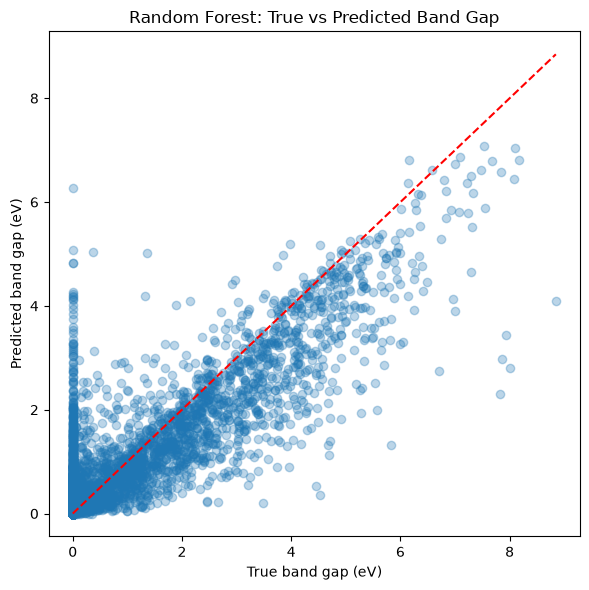

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("True band gap (eV)")
plt.ylabel("Predicted band gap (eV)")
plt.title("Random Forest: True vs Predicted Band Gap")
plt.tight_layout()
plt.show()

In [19]:
import joblib
joblib.dump(rf, "rf_bandgap_model.joblib")

['rf_bandgap_model.joblib']

In [21]:
import os
os.makedirs("notebooks/models", exist_ok=True)

In [22]:
import joblib

joblib.dump(
    rf,
    "notebooks/models/rf_bandgap_model.joblib"
)

['notebooks/models/rf_bandgap_model.joblib']

In [23]:
import os
os.path.exists("notebooks/models/rf_bandgap_model.joblib")

True

In [25]:
import os
os.makedirs("notebooks/results", exist_ok=True)

In [26]:
feature_importance.to_csv(
    "notebooks/results/rf_feature_importance.csv",
    index=False
)

In [27]:
os.path.exists(
    "notebooks/results/rf_feature_importance.csv"
)

True

In [28]:
results = {
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}

print(results)

{'MAE': 0.2862173256038027, 'RMSE': 0.619288234140622, 'R2': 0.7692931325281348}


In [29]:
import pandas as pd

pd.DataFrame([results]).to_csv(
    "notebooks/results/rf_metrics.csv",
    index=False
)

In [30]:
import os

for root, dirs, files in os.walk("notebooks"):
    for f in files:
        print(os.path.join(root, f))

notebooks/01_data_exploration.ipynb
notebooks/models/rf_bandgap_model.joblib
notebooks/results/rf_feature_importance.csv
notebooks/results/rf_metrics.csv
notebooks/.ipynb_checkpoints/01_data_exploration-checkpoint.ipynb
notebooks/data/processed/bandgap_train.parquet
notebooks/data/processed/bandgap_features.parquet
notebooks/data/processed/bandgap_test.parquet


In [31]:
import os
import joblib
import pandas as pd

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

joblib.dump(rf, "models/rf_bandgap_model.joblib")

feature_importance.to_csv("results/rf_feature_importance.csv", index=False)

pd.DataFrame([{
    "model": "RandomForestRegressor",
    "MAE": mae,
    "RMSE": rmse,
    "R2": r2
}]).to_csv("results/rf_metrics.csv", index=False)

In [32]:
import os

print(os.path.exists("models/rf_bandgap_model.joblib"))
print(os.path.exists("results/rf_feature_importance.csv"))
print(os.path.exists("results/rf_metrics.csv"))

True
True
True


In [34]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 10.1 MB/s  0:00:005.4 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [38]:
from xgboost import XGBRegressor

In [39]:
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor

In [40]:
import os

os.chdir("/Users/anitanam/optical_materials_ml")

print(os.getcwd())

/Users/anitanam/optical_materials_ml


In [41]:
train_df = pd.read_parquet(
    "notebooks/data/processed/bandgap_train.parquet"
)

test_df = pd.read_parquet(
    "notebooks/data/processed/bandgap_test.parquet"
)

print(train_df.shape)
print(test_df.shape)

(44105, 134)
(7784, 134)


In [42]:
target = "optb88vdw_bandgap"

X_train = train_df.drop(
    columns=["reduced_formula", target]
)

y_train = train_df[target]

X_test = test_df.drop(
    columns=["reduced_formula", target]
)

y_test = test_df[target]

print(X_train.shape)
print(X_test.shape)

(44105, 132)
(7784, 132)


In [43]:
xgb = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

In [44]:
xgb_mae = mean_absolute_error(
    y_test,
    xgb_preds
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_preds
) ** 0.5

xgb_r2 = r2_score(
    y_test,
    xgb_preds
)

print("XGB MAE :", xgb_mae)
print("XGB RMSE:", xgb_rmse)
print("XGB R²  :", xgb_r2)

XGB MAE : 0.27782917263594537
XGB RMSE: 0.5689877447120911
XGB R²  : 0.8052485547695509
